In [1]:
import sys
import os
sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# Now we can safely import atlasopenmagic
import atlasopenmagic as atom

In [2]:
import uproot # for reading .root files
import time # to measure time to analyse
import math # for mathematical functions such as square root
import awkward as ak # for handling complex and nested data structures efficiently
import numpy as np # # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import vector #to use vectors
import requests # for HTTP access
import aiohttp # HTTP client support
import pandas as pd
import json

import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

from sklearn.neural_network import MLPClassifier

from sklearn import datasets
from sklearn.datasets import fetch_openml
import tensorflow  as tf
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
CONFIG_FILE = "ml_config.json"

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

In [4]:
checkpoint_dir = config["options"]["checkpoint_dir"]

In [7]:
def load_blackbox(checkpoint_dir="blackbox_checkpoint"):

    data_file = os.path.join(checkpoint_dir, "blackbox_data.parquet")
    labels_file = os.path.join(checkpoint_dir, "blackbox_labels.parquet")

    # load blackbox
    print("\nLoading blackbox...")
    if not os.path.exists(data_file):
        raise RuntimeError(f"No final blackbox found: {data_file}")
    
    data = ak.from_parquet(data_file)
    print(f"Loaded {len(data)} events from {data_file}")

    # load labels
    print("\nLoading labels...")
    if not os.path.exists(labels_file):
        raise RuntimeError(f"No final blackbox found: {labels_file}")
    
    labels = ak.from_parquet(labels_file)
    print(f"Loaded {len(labels)} labels from {labels_file}")


    return data, labels

In [8]:
data, labels = load_blackbox(checkpoint_dir)


Loading blackbox...
Loaded 19995 events from blackbox_checkpoint_ml/blackbox_data.parquet

Loading labels...
Loaded 19995 labels from blackbox_checkpoint_ml/blackbox_labels.parquet


In [14]:
data.lep

<Array [{pt: [26.7, ...], eta: ..., ...}, ...] type='19995 * {pt: var * flo...'>

In [15]:
# event selection criteria
mask_exactly2leptons = data.lep.n == 2

In [16]:
for i in range(150, 180):
    print(mask_exactly2leptons[i])
    print(data.lep.n[i])

True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
False
3
True
2
True
2
True
2
True
2
True
2
True
2


In [17]:
# define mask with filter criterium
data_2lep = data[mask_exactly2leptons]

In [18]:
print("Number of events in the original signal dataset:", len(data))
print("Number of events with at least 2 leptons:", len(data_2lep))

Number of events in the original signal dataset: 19995
Number of events with at least 2 leptons: 19518


In [19]:
# Convert the lepton kinematic variables of the zeroth lepton in each event to PyTorch tensors.
# The [:,0] indexing selects the zeroth lepton from each event.
# We also define the datatype for each array - this makes things faster

lepton0_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,0] , dtype=torch.float32)
lepton0_eta_tensor = torch.tensor(data_2lep.lep.eta[:,0], dtype=torch.float32)
lepton0_phi_tensor = torch.tensor(data_2lep.lep.phi[:,0], dtype=torch.float32)
lepton0_e_tensor   = torch.tensor(data_2lep.lep.e[:,0]  , dtype=torch.float32)

lepton1_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,1] , dtype=torch.float32)
lepton1_eta_tensor = torch.tensor(data_2lep.lep.eta[:,1], dtype=torch.float32)
lepton1_phi_tensor = torch.tensor(data_2lep.lep.phi[:,1], dtype=torch.float32)
lepton1_e_tensor   = torch.tensor(data_2lep.lep.e[:,1]  , dtype=torch.float32)

In [20]:
# stack the tensors into a single tensor
input_tensor = torch.stack([lepton0_pt_tensor,
             lepton0_eta_tensor,
             lepton0_phi_tensor,
             lepton0_e_tensor,
             lepton1_pt_tensor,
             lepton1_eta_tensor,
             lepton1_phi_tensor,
             lepton1_e_tensor,
             ], dim=1)

In [21]:
# define the target
labels_2lep = labels[mask_exactly2leptons]

target_tensor = torch.tensor(labels_2lep, dtype=torch.float32)

In [22]:
target_tensor

tensor([0., 0., 1.,  ..., 0., 0., 1.])

In [23]:
# train test split
X_train, X_test = train_test_split(input_tensor, test_size=0.2, random_state=4)
Y_train, Y_test = train_test_split(target_tensor, test_size=0.2, random_state=4)

In [24]:
# Compute the mean and standard deviation
mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)

# Transform step: Apply the standardization formula
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

In [25]:
device = "cpu"
X_train_scaled = X_train_scaled.to(device)
X_test_scaled = X_test_scaled.to(device)

Y_train = Y_train.to(device)
Y_test = Y_test.to(device)

In [26]:
# =========== PyTorch Approach ============ #
model = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Our model should live on the same device as our tensors
model = model.to(device)

In [ ]:
# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [28]:
train_losses = []
test_losses = []

N_epochs = 100

for epoch in range(N_epochs):

    model.train()
    # tell the optimizer to begin an optimization step
    optimizer.zero_grad()

    # forward pass
    # use the model as a prediction function: features → predictions
    predictions = model(X_train_scaled)

    # compute the loss between these predictions and the intended targets
    loss = criterion(predictions.squeeze(), Y_train)

    # Compute the gradients of the loss wrt the trainable parameters
    loss.backward()

    # Update the model parameters based on the gradients
    optimizer.step()

    # Purely for monitoring and visualisation: keeping track of the losses
    train_losses.append(loss.item())


    # validation
    model.eval()

    with torch.no_grad():
        test_predictions = model(X_test_scaled)
        test_loss = criterion(test_predictions.squeeze(), Y_test)

    test_losses.append(test_loss.item())

    print(
        f'Epoch [{epoch + 1}/{N_epochs}], '
        f'Train Loss: {loss.item():.4f}, '
        f'Test Loss: {test_loss.item():.4f}')

Epoch [1/100], Train Loss: 0.7097, Test Loss: 0.6726
Epoch [2/100], Train Loss: 0.6763, Test Loss: 0.6432
Epoch [3/100], Train Loss: 0.6453, Test Loss: 0.6154
Epoch [4/100], Train Loss: 0.6166, Test Loss: 0.5887
Epoch [5/100], Train Loss: 0.5893, Test Loss: 0.5628
Epoch [6/100], Train Loss: 0.5628, Test Loss: 0.5373
Epoch [7/100], Train Loss: 0.5369, Test Loss: 0.5120
Epoch [8/100], Train Loss: 0.5114, Test Loss: 0.4867
Epoch [9/100], Train Loss: 0.4859, Test Loss: 0.4615
Epoch [10/100], Train Loss: 0.4606, Test Loss: 0.4363
Epoch [11/100], Train Loss: 0.4355, Test Loss: 0.4113
Epoch [12/100], Train Loss: 0.4106, Test Loss: 0.3866
Epoch [13/100], Train Loss: 0.3861, Test Loss: 0.3623
Epoch [14/100], Train Loss: 0.3620, Test Loss: 0.3386
Epoch [15/100], Train Loss: 0.3387, Test Loss: 0.3157
Epoch [16/100], Train Loss: 0.3161, Test Loss: 0.2938
Epoch [17/100], Train Loss: 0.2946, Test Loss: 0.2731
Epoch [18/100], Train Loss: 0.2743, Test Loss: 0.2536
Epoch [19/100], Train Loss: 0.2552, T

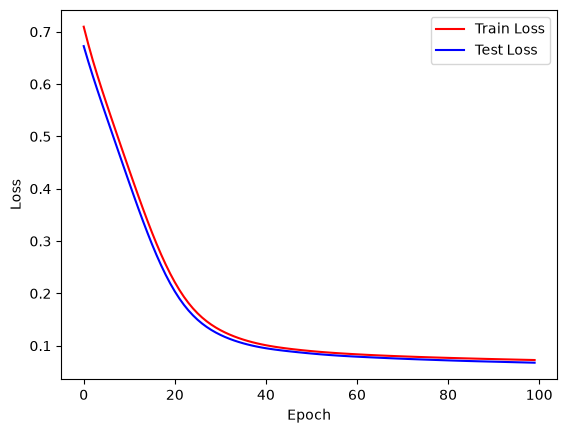

In [29]:
# plot loss function for training and validation sets
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(test_losses, label='Test Loss', color='blue')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

tensor([[0.0058],
        [1.0000],
        [0.0090],
        ...,
        [0.9999],
        [1.0000],
        [0.9995]])
0.977202868852459


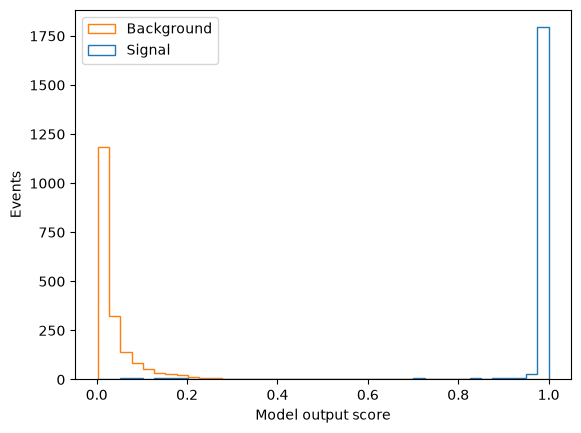

In [30]:
# Model evaluation is simple: call the model
# We detach the array
y_pred = model(X_test_scaled).detach()
print(y_pred)

# Plot the scores
#plt.hist(y_pred,bins=40)
#plt.xlabel('Model output score')
#plt.ylabel('Events')

threshold = 0.5
y_pred_labels = (y_pred >= threshold).float()

accuracy = accuracy_score(Y_test, y_pred_labels)
print(accuracy)

# Plotting the model outputs for signal and background separately
signal_scores = y_pred[Y_test == 1].flatten()
background_scores = y_pred[Y_test == 0].flatten()
plt.hist([signal_scores,background_scores], bins=40, histtype='step', label=['Signal','Background'])
plt.legend()
plt.xlabel('Model output score')
plt.ylabel('Events')
plt.savefig("pytorch.pdf")
plt.show()

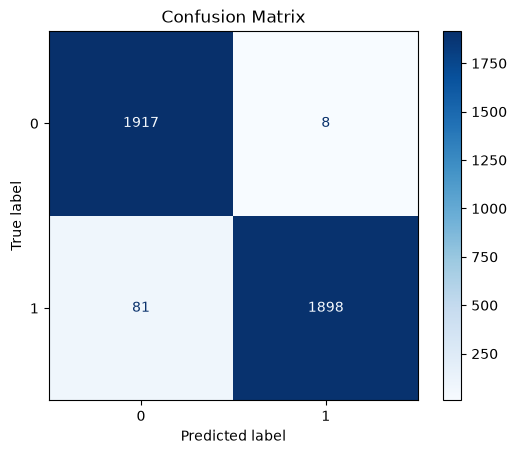

In [31]:
# modell in evaluation mode
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_scaled).squeeze()

    # probabilities
    test_predicted_classes = (test_predictions >= 0.5).int()

# confusion matrix
cm = confusion_matrix(
    Y_test.cpu().numpy(),
    test_predicted_classes.cpu().numpy()
)

# plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [32]:
# =========== Scikit Approach ============ #
nn_deep = MLPClassifier(
    hidden_layer_sizes=(64, 64, 64, 64),   # FOUR hidden layers -- a "deep" network
    activation='relu',
    max_iter=2000,
    random_state=4,
)
nn_deep.fit(X_train_scaled, Y_train)

score_nn_deep_test = nn_deep.predict_proba(X_test_scaled)[:, 1]
score_nn_deep_test

array([4.13061481e-04, 1.00000000e+00, 2.31307256e-05, ...,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00], shape=(3904,))

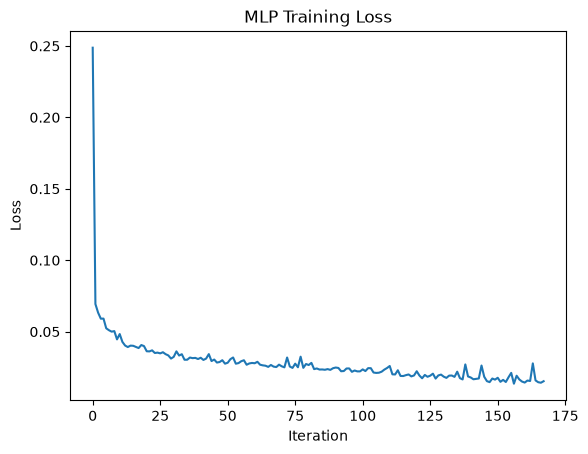

In [33]:
plt.plot(nn_deep.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.show()

Accuracy: 0.9900


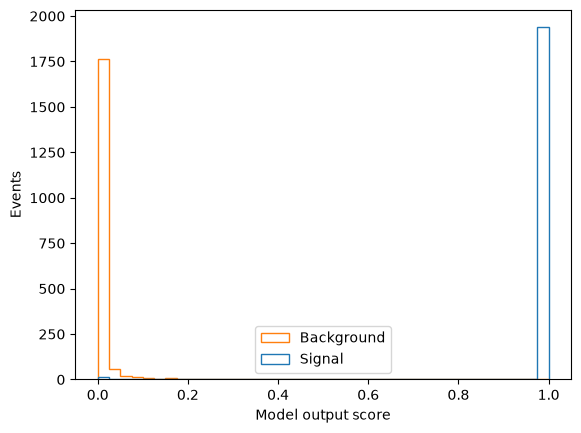

In [34]:
threshold = 0.5

# Continuous model output -> binary prediction
y_pred_labels = (score_nn_deep_test >= threshold).astype(int)

accuracy = accuracy_score(Y_test, y_pred_labels)
print(f"Accuracy: {accuracy:.4f}")

# Scores getrennt nach Signal und Background
signal_scores = score_nn_deep_test[Y_test == 1]
background_scores = score_nn_deep_test[Y_test == 0]

# Plot
plt.hist(
    [signal_scores, background_scores],
    bins=40,
    histtype='step',
    label=['Signal', 'Background']
)

plt.legend()
plt.xlabel('Model output score')
plt.ylabel('Events')
plt.savefig("scikit.pdf")
plt.show()

In [35]:
# =========== TensorFlow Keras Approach ============ #
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, input_shape=(8,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(64),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=(8,)),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/Users/baeumann/.pyenv/versions/atlas-open-data/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# preprocess data
X_train_tf = X_train_scaled.detach().cpu().numpy()
X_test_tf = X_test_scaled.detach().cpu().numpy()

Y_train_tf = Y_train.detach().cpu().numpy()
Y_test_tf = Y_test.detach().cpu().numpy()

In [37]:
earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0005,
    patience=10,
    restore_best_weights=True
)

low_history = tf_model.fit(
    X_train_tf,
    Y_train_tf,
    epochs=70,
    batch_size=32,
    validation_data=(X_test_tf, Y_test_tf),
    verbose=1
)

Epoch 1/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.9020 - loss: 0.2864 - val_accuracy: 0.9631 - val_loss: 0.1134
Epoch 2/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - accuracy: 0.9663 - loss: 0.0991 - val_accuracy: 0.9705 - val_loss: 0.0824
Epoch 3/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - accuracy: 0.9718 - loss: 0.0814 - val_accuracy: 0.9767 - val_loss: 0.0726
Epoch 4/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.9748 - loss: 0.0743 - val_accuracy: 0.9772 - val_loss: 0.0663
Epoch 5/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.9768 - loss: 0.0705 - val_accuracy: 0.9790 - val_loss: 0.0637
Epoch 6/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - accuracy: 0.9770 - loss: 0.0684 - val_accuracy: 0.9795 - val_loss: 0.0615
Epoch 7/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - accuracy: 0.9773 - loss: 0.0670 - val_accuracy: 0.9805 - val_loss: 0.0586
Epoch 8/70
488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.9780 - loss: 0.0659 - 

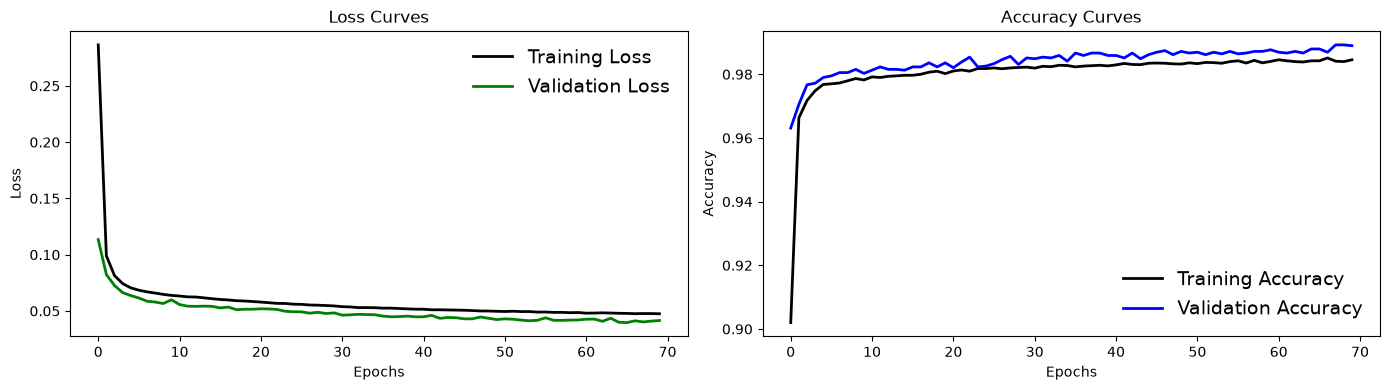

In [38]:
# Loss & Accuracycurve
plt.figure(figsize=[14,4])

plt.subplot(1,2,1)
plt.plot(low_history.history['loss'], 'black', linewidth=2.0)
plt.plot(low_history.history['val_loss'], 'green', linewidth=2.0)
plt.legend(['Training Loss', 'Validation Loss'], frameon=False, fontsize=14)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.title('Loss Curves', fontsize=12)

plt.subplot(1,2,2)
plt.plot(low_history.history['accuracy'], 'black', linewidth=2.0)
plt.plot(low_history.history['val_accuracy'], 'blue', linewidth=2.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], frameon=False, fontsize=14)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.title('Accuracy Curves', fontsize=12)

plt.tight_layout()
plt.savefig("tf_ml.png")
plt.show()

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step
Accuracy: 0.9890


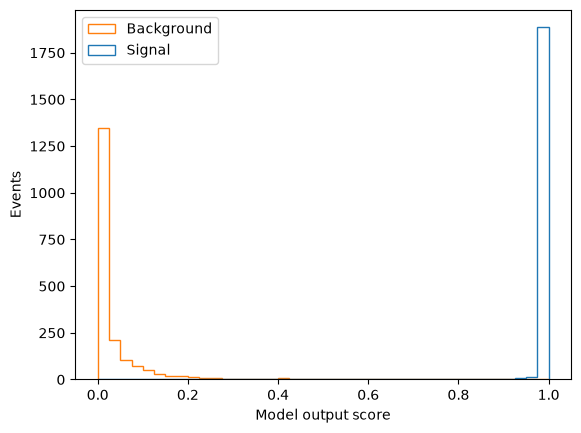

In [39]:
score_tf_test = tf_model.predict(X_test_scaled).flatten()

threshold = 0.5

y_pred_labels = (score_tf_test >= threshold).astype(int)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred_labels)
print(f"Accuracy: {accuracy:.4f}")

# Scores nach Klasse aufteilen
signal_scores = score_tf_test[Y_test == 1]
background_scores = score_tf_test[Y_test == 0]

plt.hist(
    [signal_scores, background_scores],
    bins=40,
    histtype="step",
    label=["Signal", "Background"]
)

plt.xlabel("Model output score")
plt.ylabel("Events")
plt.legend()
plt.savefig("keras.pdf")
plt.show()